In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates


plt.style.use("seaborn-v0_8")

In [2]:
df = pd.read_csv(
    r"C:\Users\r8885426\OneDrive - FRG\Documents\G4L\cpi_data_cleaned.csv"
)

cpi_weight = pd.read_excel(
    r"C:\Users\r8885426\OneDrive - FRG\Documents\G4L\cpi_weights.xlsx"
)





In [3]:
df["Month"] = pd.to_datetime(df["Month"], errors="coerce")

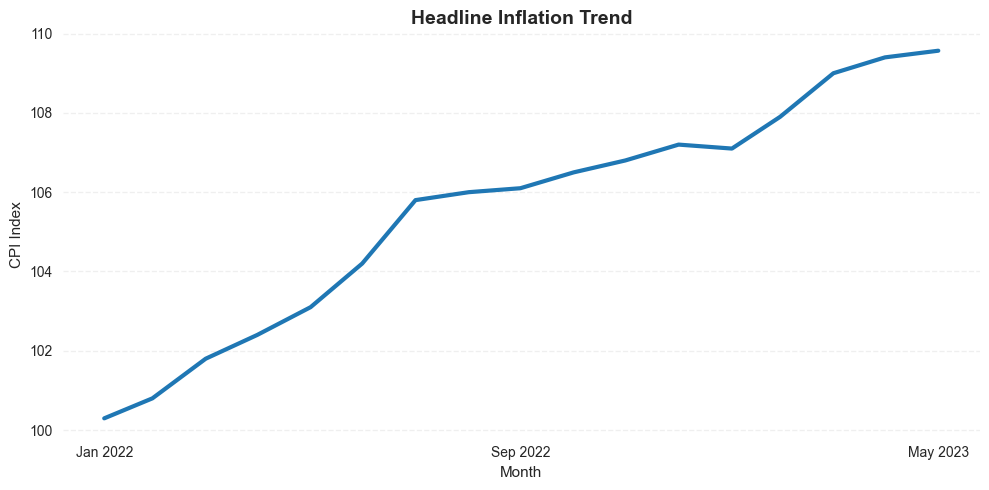

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Month is datetime
df["Month"] = pd.to_datetime(df["Month"])

# Filter Headline CPI and sort
headline = df[df["Category"] == "Headline_CPI"].sort_values("Month")

# ✅ Define first, middle, last dates
dates = headline["Month"].reset_index(drop=True)

first_date = dates.iloc[0]
middle_date = dates.iloc[len(dates) // 2]
last_date = dates.iloc[-1]

# Plot
sns.set_style("white")
plt.figure(figsize=(10, 5))

plt.plot(
    headline["Month"],
    headline["Value"],
    color="#1f77b4",
    linewidth=3
)

plt.title("Headline Inflation Trend", fontsize=14, weight="bold")
plt.ylabel("CPI Index")
plt.xlabel("Month")

# ✅ Only three x-axis ticks
plt.xticks(
    [first_date, middle_date, last_date],
    [
        first_date.strftime("%b %Y"),
        middle_date.strftime("%b %Y"),
        last_date.strftime("%b %Y"),
    ]
)

# Clean styling
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.grid(axis="x", visible=False)
sns.despine()

plt.tight_layout()
plt.show()

In [5]:
sns.set_style("white")
BLUE = "#1f77b4"
LIGHT_BLUE = "#cfe2f3"

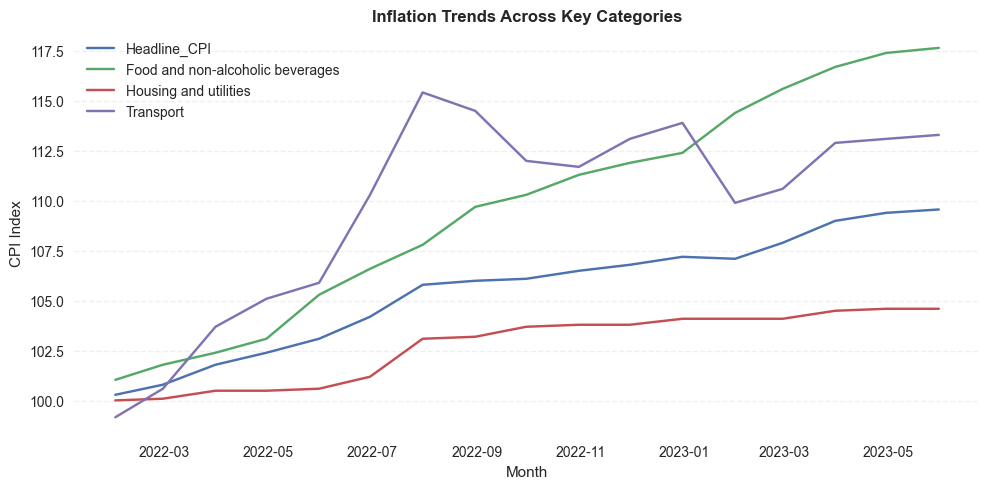

In [6]:
focus_categories = [
    "Headline_CPI",
    "Food and non-alcoholic beverages",
    "Housing and utilities",
    "Transport"
]

plt.figure(figsize=(10,5))

for cat in focus_categories:
    temp = df[df["Category"] == cat]
    plt.plot(temp["Month"], temp["Value"], label=cat)

plt.title("Inflation Trends Across Key Categories", weight="bold")
plt.ylabel("CPI Index")
plt.xlabel("Month")
plt.legend(frameon=False)
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

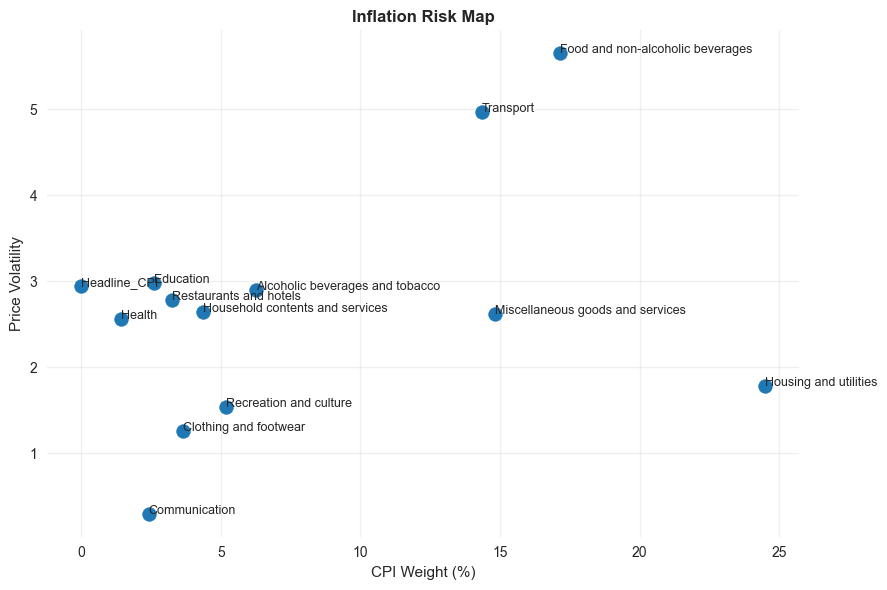

In [7]:
volatility = (
    df.groupby("Category")["Value"]
      .std()
      .reset_index(name="Volatility")
)

importance = cpi_weight.merge(volatility, on="Category", how="inner")

plt.figure(figsize=(9,6))
plt.scatter(
    importance["Weight"],
    importance["Volatility"],
    color=BLUE,
    s=100
)

for _, row in importance.iterrows():
    plt.text(
        row["Weight"],
        row["Volatility"],
        row["Category"],
        fontsize=9
    )

plt.xlabel("CPI Weight (%)")
plt.ylabel("Price Volatility")
plt.title("Inflation Risk Map", weight="bold")
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

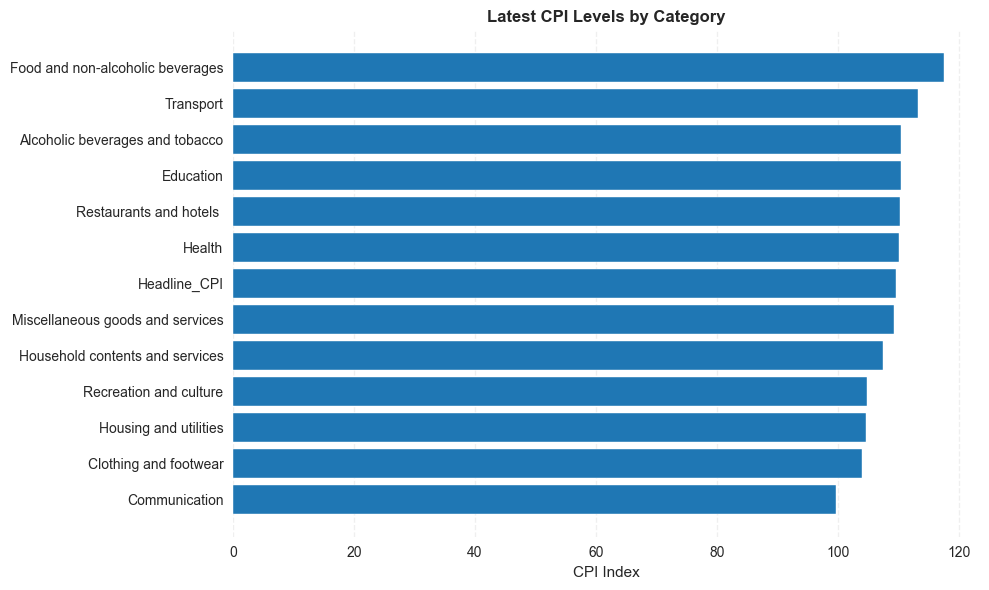

In [8]:
latest = (
    df.sort_values("Month")
      .groupby("Category")
      .last()
      .sort_values("Value", ascending=True)
)

plt.figure(figsize=(10,6))
plt.barh(latest.index, latest["Value"], color=BLUE)

plt.title("Latest CPI Levels by Category", weight="bold")
plt.xlabel("CPI Index")
plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

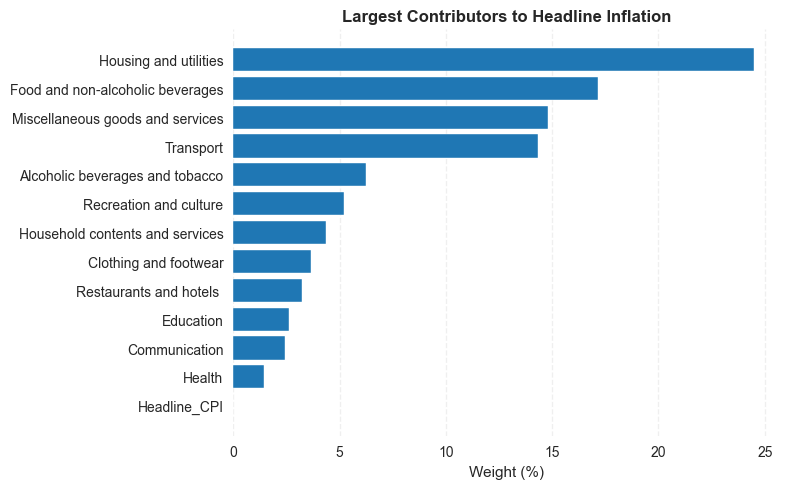

In [9]:
top_weights = cpi_weight.sort_values("Weight", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(top_weights["Category"], top_weights["Weight"], color=BLUE)

plt.title("Largest Contributors to Headline Inflation", weight="bold")
plt.xlabel("Weight (%)")
plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

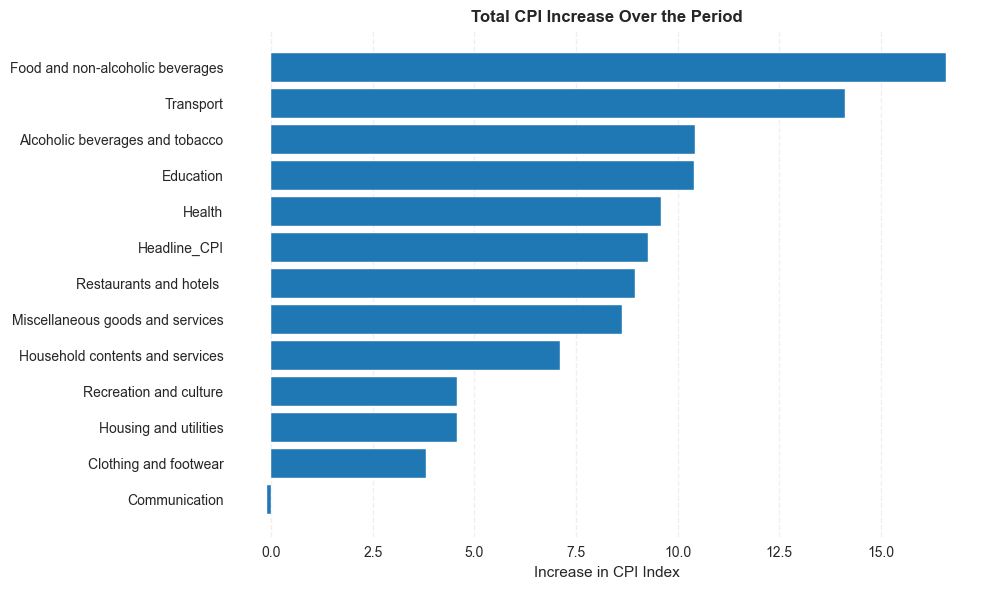

In [10]:
change = (
    df.sort_values("Month")
      .groupby("Category")
      .agg(Start=("Value","first"), End=("Value","last"))
)

change["Change"] = change["End"] - change["Start"]
change = change.sort_values("Change")

plt.figure(figsize=(10,6))
plt.barh(change.index, change["Change"], color=BLUE)

plt.title("Total CPI Increase Over the Period", weight="bold")
plt.xlabel("Increase in CPI Index")
plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

In [11]:
kpi = (
    df.groupby("Category")
      .agg(
          Latest_CPI=("Value","last"),
          Avg_Monthly_Change=("Percentage Change (From Prior Month)","mean")
      )
      .round(2)
)

kpi

,Latest_CPI,Avg_Monthly_Change
Category,,
Alcoholic beverages and tobacco,110.54,0.61
Clothing and footwear,104.04,0.24
Communication,99.70,-0.02
Education,110.40,0.59
Food and non-alcoholic beverages,117.65,0.96
Headline_CPI,109.57,0.55
Health,110.19,0.59
Household contents and services,107.50,0.44
Housing and utilities,104.60,0.27
